# Summary

L'étude de l'humidité relative apporte une éclaicissement sur la tendance vers un assèchement du climat autour de l'aéroport de Rivesaltes. Dans ce Notebook, les normales, quantiles et seuils ont été utilisés pour étudier les tendances générales ainsi que l'évolution des intensités et fréquences des phénomènes extrèmes.

Malgrè l'observation d'une tendance annuelle vers un assèchement dès 1980, les années 1991 à 1993 sont remarquablement plus humides. Cependant, aucune tempête majeure n'est enregistrée durant cette période et la transition est progressive écartant l'implication d'un changement de capteur/méthode de mesure. Par conséquent deux études, avec et sans les années 91 à 93 sont réalisées. Elles démontrent que si les annèes humides (91-93) sont prises en comptes, la normale 1990-2019 est plus humide pour l'hiver et le début du printemps par rapport à la normale 1960-1989. En opposition, la normale 1995-2024 est plus sèche sur la même période par rapport à celle de 1960-1989. Concernant les périodes estivale et automnale, le signal d'assèchement est présent sur pour les deux normales. Afin d'étudier l'impact des dernières années (2020-2024) sur la normale, nous avons sélectionné la période 1995-2024.

Par convention, les résultats seront calculés sur la période la plus récente (1995-2024), en comparaison avec la période la plus ancienne (1960-1989). De plus, l'unité de l'humidité relative est le %. Par conséquent, si aucune mention n'est faite, les résultats présentés en % référeront à l'unité.

Via les normales, nous observons un clair assèchement sur les périodes estivales et automnales, avec respectivement -3,3% et -3,6%, tandis que l'humidité relative des hivers et printemps reste similaire. Cette analyse est confirmée par l'utilisation des moyennes mobiles qui accentuent l'assèchemnent sur l'été (-3,8%) et montrent, cette fois, une perte d'humidité globale sur toutes les saisons.

L'analyse des quantiles confirme ce net décalage de la distribution vers un environnement plus sec. Ainsi la médiane est en moyenne 3,7% plus sèche en été et automne et 1% plus sèche en hiver. Cette tendance se retrouve sur le quantile 10, démontrant une intensification des évènements secs que ce soit en été ou hiver. En parallèle, le quantile 90 perd en humidité de 3% en été, 2,4% en automne et 1% au printemps, démontrant cette tendance d'assèchement quasi global. Cependant, les évènements humides en hiver conservent leur intensité. Ce constat est retrouvé sur les autres quantiles et max/min confirmant un décalage vers un climat plus sec, principalement en été et automne. Le signal est plus contrasté en hiver/printemps avec la conservation de l'intensité des évènements humides malgrè un assèchement léger mais progressif de la distribution.

En parallèle, la fréquence des évènements secs en été (moins de 50% hu) a été multiplié presque par 2 depuis le début du siècle, passant de 16 à 29 jours par an. La tendance s'observe aussi sur la période automnale avec une fréquence observée similaire à celle estivale. En opposition, une tendance à la réduction progressive des jours très humides en té et automne est observée.

# Imports

In [1]:
import os

import packages.computing as cp

from packages.mining import open_data
from packages.plotting import plot_data, norm_compare

directory = os.chdir("/home/leopaul/Climate_Change_PO/")

In [2]:
sr = open_data(
    "data/FRNOR.RR2025010565429.PPDH.KEYuAAuu91dxAxu2BfU7xuA.csv",
    "U"
)

/home/leopaul/Climate_Change_PO/packages/mining.py:26: DtypeWarning: Columns (2,3,6,7,9,10,11,13,17,18,19,21,23,24,25,27,29,40,41,45,49,51,53,55,57,59) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(path, sep=';', encoding='utf-8')


DatetimeIndex(['1930-08-01 00:00:00', '1930-08-01 03:00:00',
               '1930-08-01 06:00:00', '1930-08-01 09:00:00',
               '1930-08-01 12:00:00', '1930-08-01 15:00:00',
               '1930-08-01 21:00:00', '1930-08-02 00:00:00',
               '1930-08-02 03:00:00', '1930-08-02 06:00:00',
               ...
               '2025-06-28 03:00:00', '2025-06-28 06:00:00',
               '2025-06-28 09:00:00', '2025-06-28 12:00:00',
               '2025-06-28 15:00:00', '2025-06-28 18:00:00',
               '2025-06-28 21:00:00', '2025-06-29 00:00:00',
               '2025-06-29 03:00:00', '2025-06-29 06:00:00'],
              dtype='datetime64[ns]', name='DATE', length=46223, freq=None)


In [3]:
sr_stdy = sr.loc["1960-01-01 00:00:00":"2019-12-31 23:00:00"]
dates_nan = sr_stdy[sr_stdy.isna()].index
nan_by_year = sr_stdy.isna().groupby(sr_stdy.index.year).sum()
nan_by_year = nan_by_year[nan_by_year != 0]
print(nan_by_year)
print(dates_nan)

DATE
1966     1
2005     2
2012     1
2013     2
2014     1
2016     3
2017     7
2019    45
Name: U, dtype: int64
DatetimeIndex(['1966-12-11 21:00:00', '2005-03-17 00:00:00',
               '2005-03-17 03:00:00', '2012-02-04 03:00:00',
               '2013-07-18 00:00:00', '2013-07-18 03:00:00',
               '2014-09-12 09:00:00', '2016-09-04 00:00:00',
               '2016-09-04 03:00:00', '2016-09-04 06:00:00',
               '2017-01-28 00:00:00', '2017-01-28 03:00:00',
               '2017-02-05 21:00:00', '2017-02-06 00:00:00',
               '2017-02-06 03:00:00', '2017-02-06 06:00:00',
               '2017-02-06 09:00:00', '2019-06-04 09:00:00',
               '2019-07-26 18:00:00', '2019-07-26 21:00:00',
               '2019-07-27 00:00:00', '2019-07-27 03:00:00',
               '2019-07-27 06:00:00', '2019-07-27 09:00:00',
               '2019-07-27 12:00:00', '2019-07-27 15:00:00',
               '2019-07-27 18:00:00', '2019-07-27 21:00:00',
               '2019-07-28 00:0

# Daily Hu

## General view

DATE
2019    3
Name: U, dtype: int64
DatetimeIndex(['2019-07-27', '2019-07-28', '2019-08-18'], dtype='datetime64[ns]', name='DATE', freq=None)


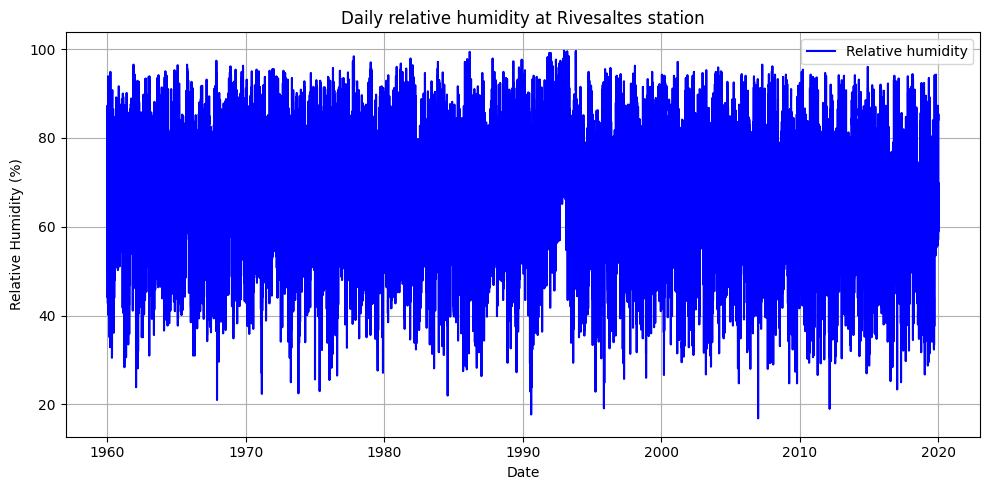

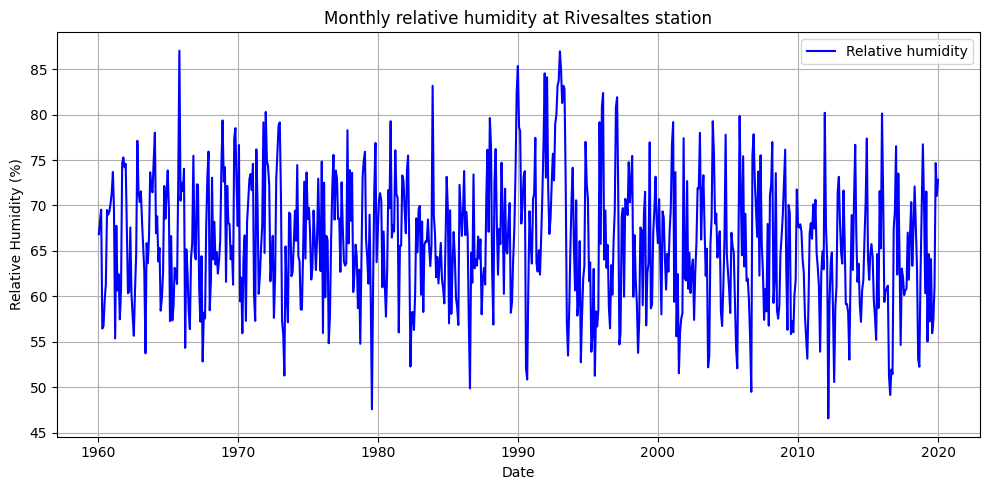

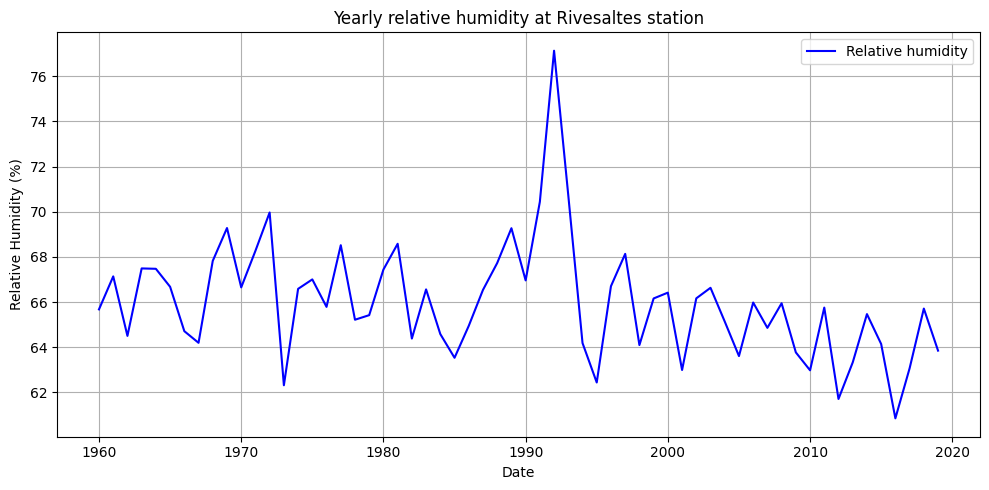

In [4]:
sr_d = sr_stdy.resample("D").mean()
dates_nan = sr_d[sr_d.isna()].index
nan_by_year = sr_d.isna().groupby(sr_d.index.year).sum()
nan_by_year = nan_by_year[nan_by_year != 0]
print(nan_by_year)
print(dates_nan)

plot_data(
    sr_d,
    "Relative humidity",
    "Daily relative humidity",
    "humidity/daily_humidity"
)

sr_m = sr_stdy.resample("ME").mean()
plot_data(
    sr_m,
    "Relative humidity",
    "Monthly relative humidity",
    "humidity/monthly_humidity"
)

sr_y = sr_stdy.resample("YE", label="left").mean()
plot_data(
    sr_y,
    "Relative humidity",
    "Yearly relative humidity",
    "humidity/yearly_humidity"
)

## Climatology

### Normal

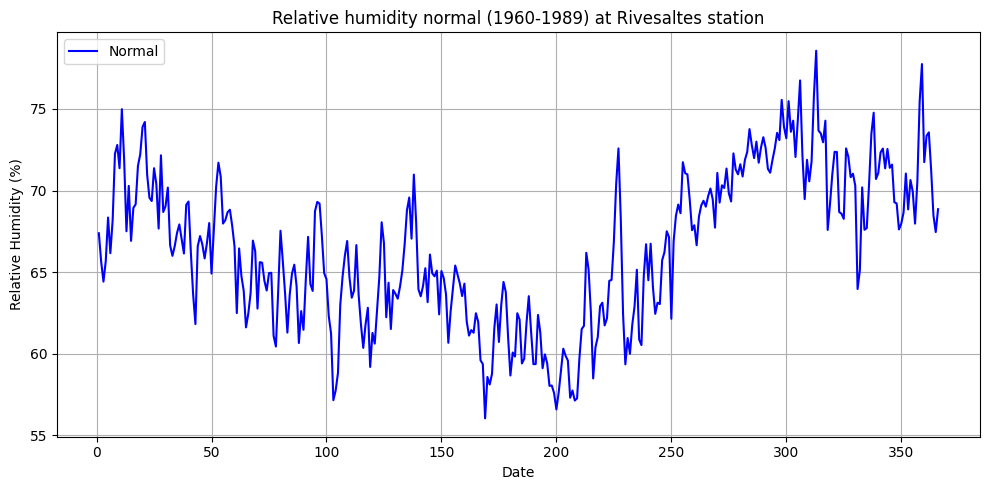

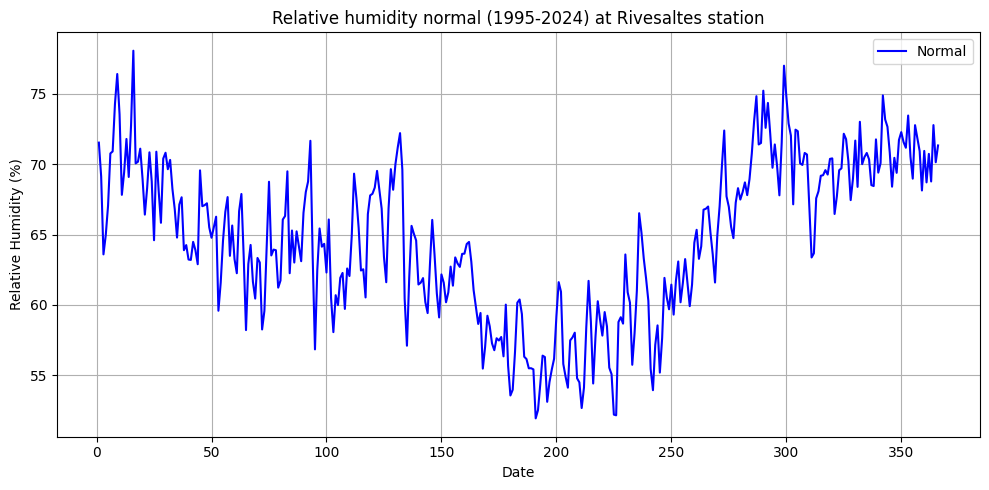

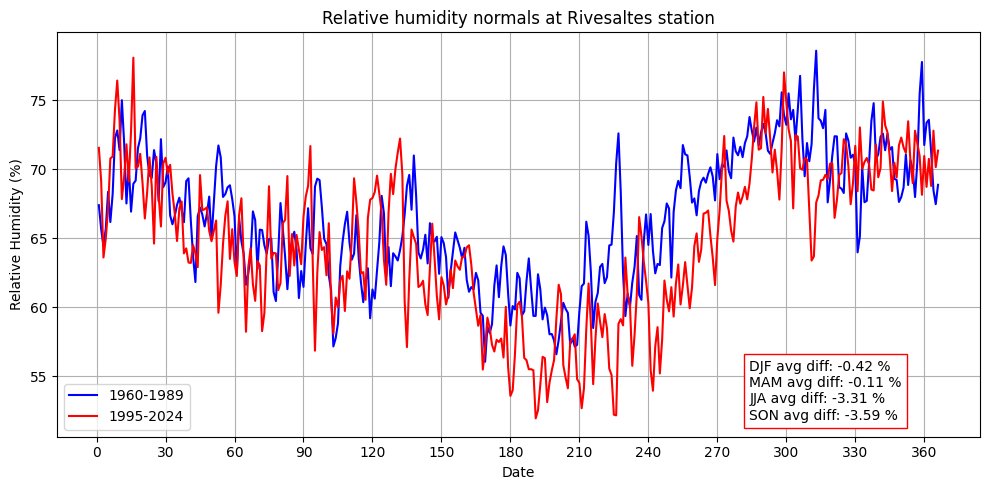

In [5]:
# Containing the highest humidity years
sr_nrm_f = cp.normal(
    sr_stdy,
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "Relative humidity",
    "humidity"
)

sr_nrm_s = cp.normal(
    sr_stdy,
    "1995-01-01 00:00:00",
    "2024-12-31 23:00:00",
    "Relative humidity",
    "humidity"
)

norm_compare(
    sr_nrm_f,
    sr_nrm_s,
    "Relative humidity normals at Rivesaltes station",
    "Relative Humidity (%)",
    "1960-1989",
    "1995-2024",
    "%"
)

### Quantiles

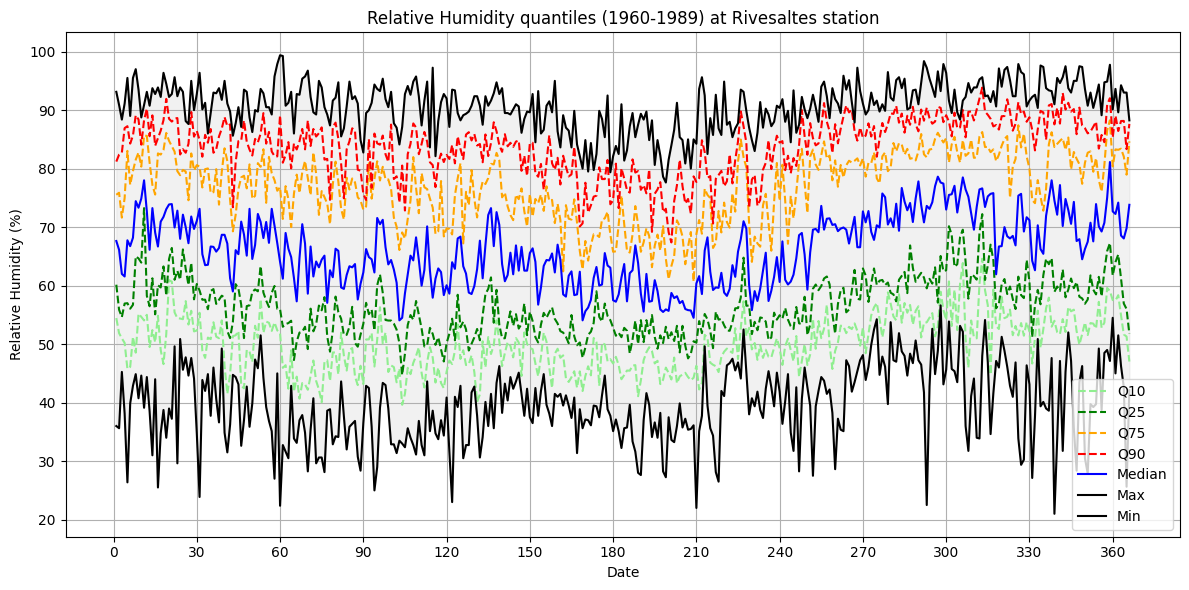

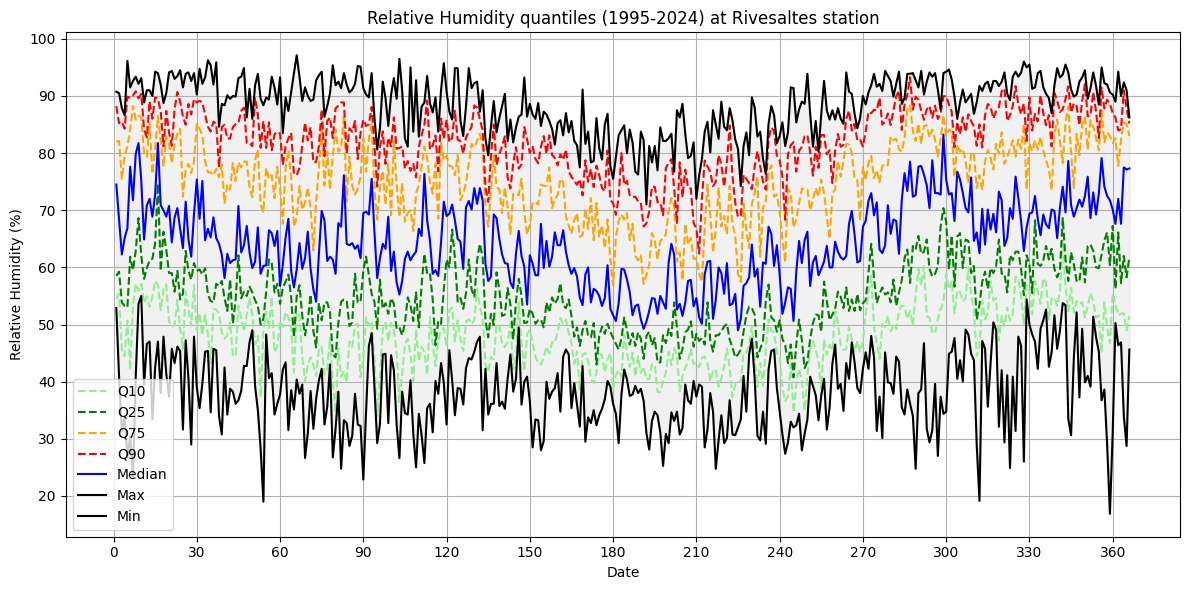

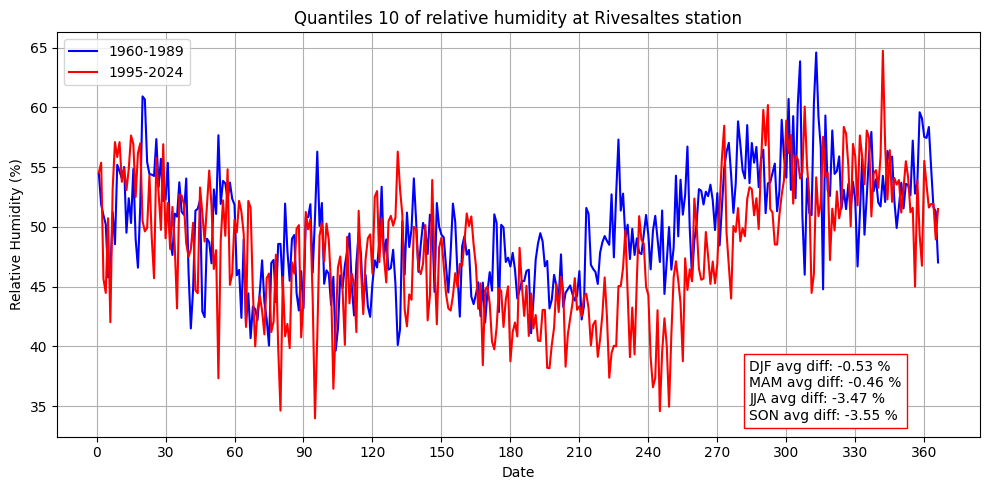

In [6]:
sr_frst = sr_stdy.loc["1960-01-01 00:00:00":"1989-12-31 23:00:00"]
sr_snd = sr_stdy.loc["1995-01-01 00:00:00":"2024-12-31 23:00:00"]

dic_q_f = cp.quantiles(
    sr_frst,
    "avg",
    "Relative Humidity quantiles (1960-1989) at Rivesaltes station",
    "Relative Humidity (%)",
    "humidity/quantiles_1960_1989",
)

dic_q_s = cp.quantiles(
    sr_snd,
    "avg",
    "Relative Humidity quantiles (1995-2024) at Rivesaltes station",
    "Relative Humidity (%)",
    "humidity/quantiles_1990_2019",
)

q_f = dic_q_f["Q10"]
q_s = dic_q_s["Q10"]

norm_compare(
    q_f,
    q_s,
    "Quantiles 10 of relative humidity at Rivesaltes station",
    "Relative Humidity (%)",
    "1960-1989",
    "1995-2024",
    "%"
)

### Moving average

#### Normal

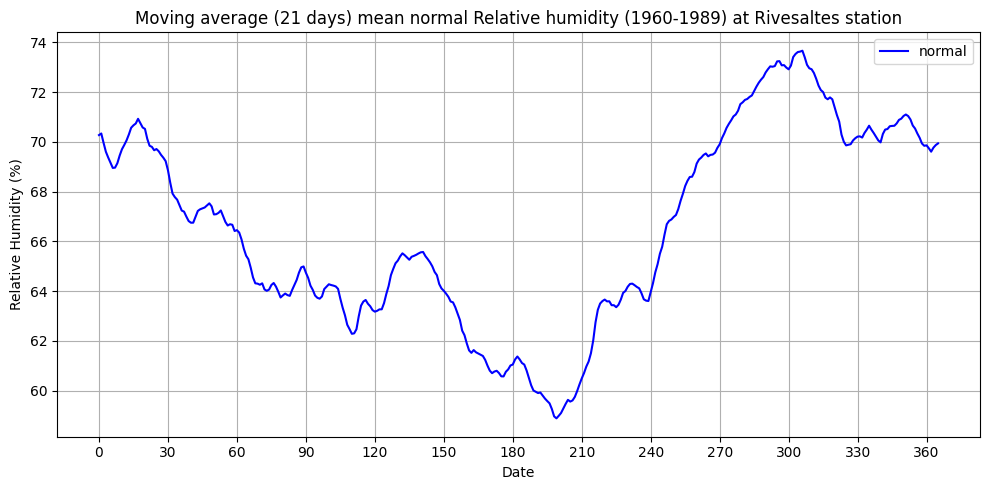

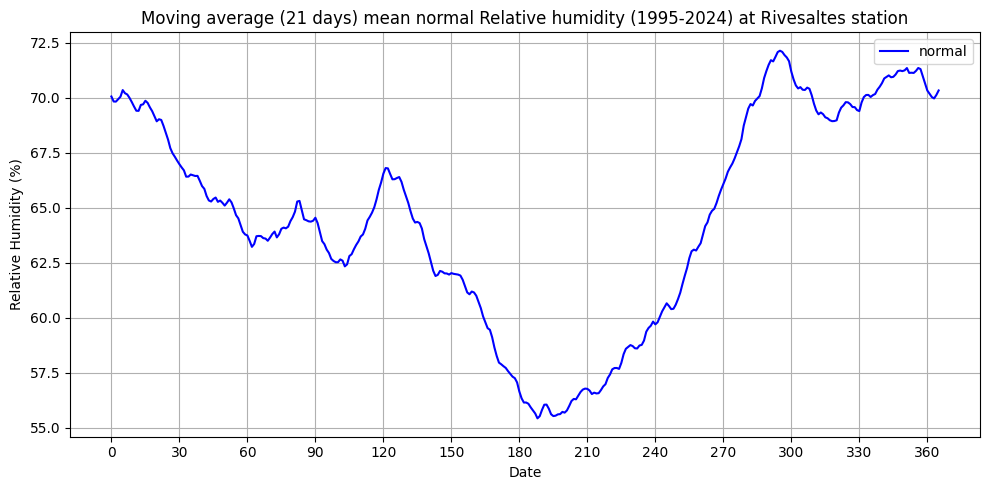

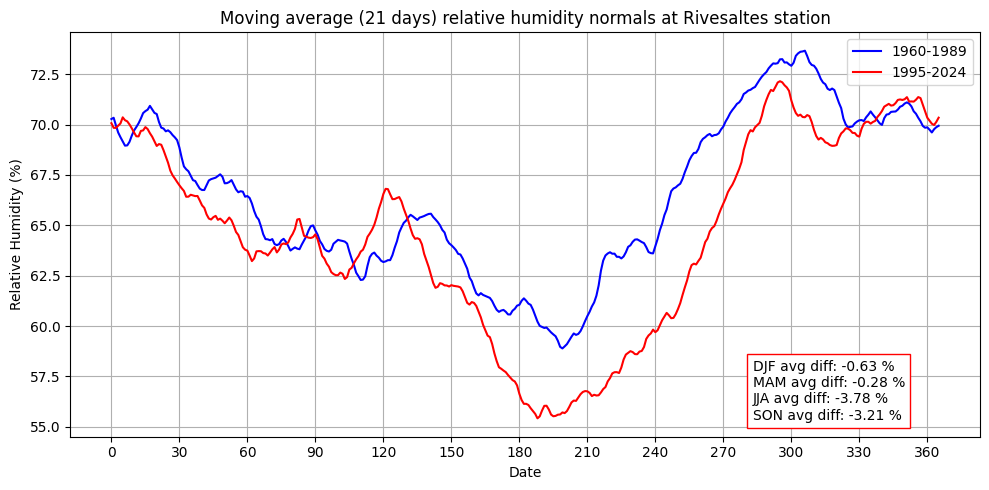

In [7]:
sr_nrm_f = cp.clim_ma(
    sr,
    "Relative humidity",
    21,
    "mean",
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "humidity",
    True
)

sr_nrm_s = cp.clim_ma(
    sr,
    "Relative humidity",
    21,
    "mean",
    "1995-01-01 00:00:00",
    "2024-12-31 23:00:00",
    "humidity",
    True
)

norm_compare(
    sr_nrm_f,
    sr_nrm_s,
    "Moving average (21 days) relative humidity normals at Rivesaltes station",
    "Relative Humidity (%)",
    "1960-1989",
    "1995-2024",
    "%"
)

#### Quantiles

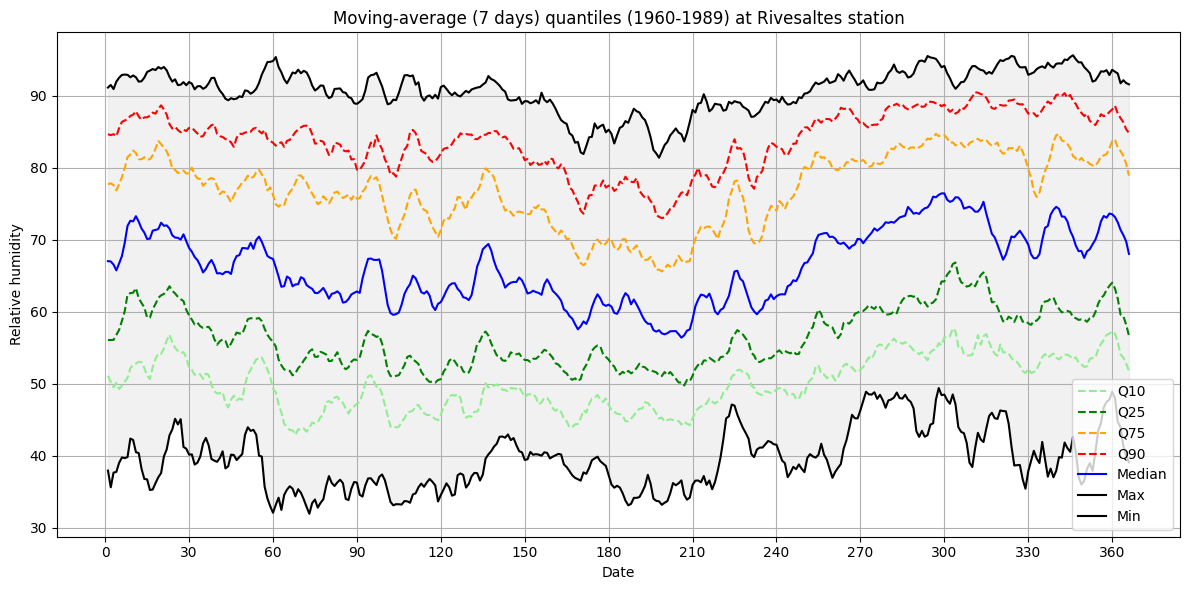

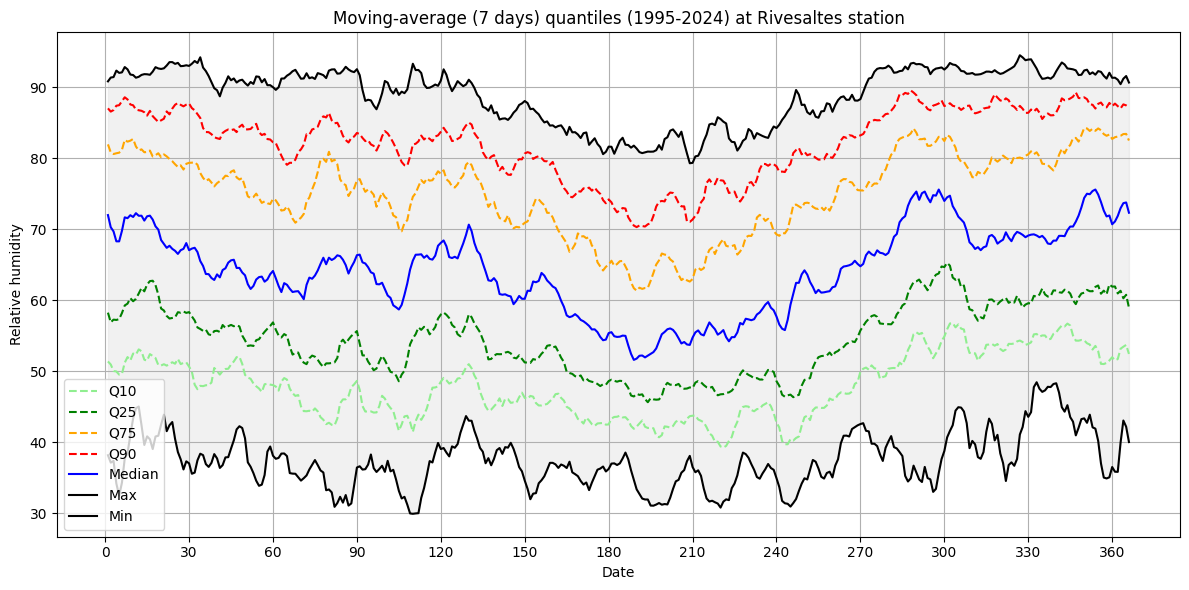

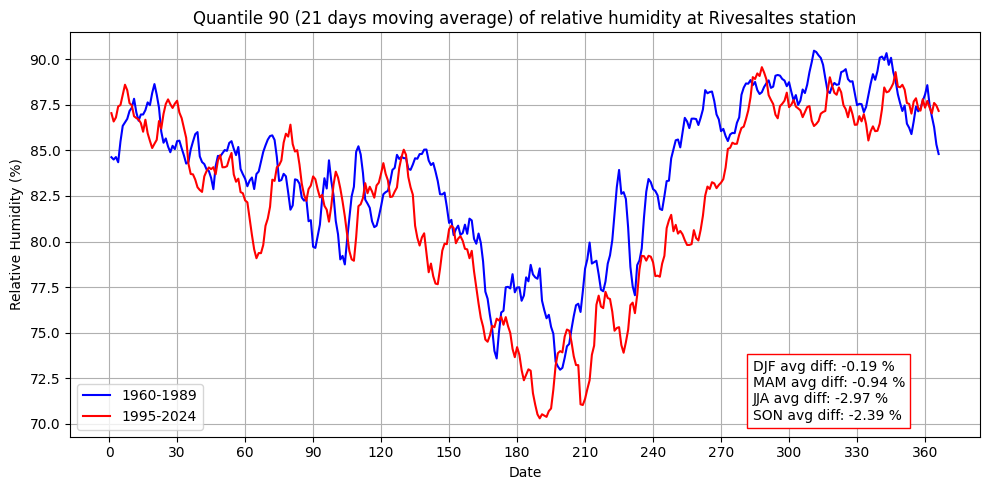

In [8]:
dic_ma_q_f = cp.ma_quantiles(
    sr,
    7,
    "avg",
    "1960-01-01 00:00:00",
    "1989-12-31 23:00:00",
    "Moving-average (7 days) quantiles (1960-1989) at Rivesaltes station",
    "Relative humidity",
    "humidity"
)

dic_ma_q_s = cp.ma_quantiles(
    sr,
    7,
    "avg",
    "1995-01-01 00:00:00",
    "2024-12-31 23:00:00",
    "Moving-average (7 days) quantiles (1995-2024) at Rivesaltes station",
    "Relative humidity",
    "humidity"
)

q_f = dic_ma_q_f["Q90"]
q_s = dic_ma_q_s["Q90"]

norm_compare(
    q_f,
    q_s,
    "Quantile 90 (21 days moving average) of relative humidity at Rivesaltes station",
    "Relative Humidity (%)",
    "1960-1989",
    "1995-2024",
    "%"
)

### Thresholds

The corresponding dates are : [Timestamp('1960-01-03 00:00:00'), Timestamp('1960-01-10 00:00:00'), Timestamp('1960-01-13 00:00:00'), Timestamp('1960-01-15 00:00:00'), Timestamp('1960-01-16 00:00:00'), Timestamp('1960-01-17 00:00:00'), Timestamp('1960-01-18 00:00:00'), Timestamp('1960-01-27 00:00:00'), Timestamp('1960-01-29 00:00:00'), Timestamp('1960-01-30 00:00:00'), Timestamp('1960-01-31 00:00:00'), Timestamp('1960-02-01 00:00:00'), Timestamp('1960-02-06 00:00:00'), Timestamp('1960-02-07 00:00:00'), Timestamp('1960-02-15 00:00:00'), Timestamp('1960-02-23 00:00:00'), Timestamp('1960-02-27 00:00:00'), Timestamp('1960-12-09 00:00:00'), Timestamp('1960-12-11 00:00:00'), Timestamp('1960-12-12 00:00:00'), Timestamp('1960-12-13 00:00:00'), Timestamp('1960-12-15 00:00:00'), Timestamp('1961-01-05 00:00:00'), Timestamp('1961-01-09 00:00:00'), Timestamp('1961-02-04 00:00:00'), Timestamp('1961-02-07 00:00:00'), Timestamp('1961-02-09 00:00:00'), Timestamp('1961-02-10 00:00:00'), Timestamp('1961-0

<Figure size 600x500 with 0 Axes>

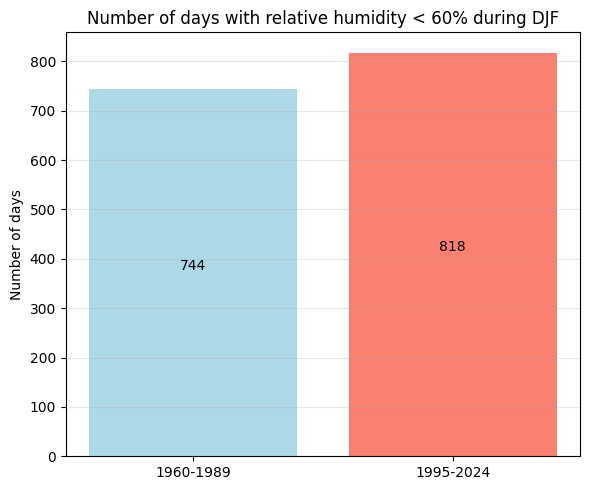

In [9]:
sr_thresholds_d = sr.resample("D").mean()

sr_frst_d = sr_thresholds_d.loc["1960-01-01 00:00:00":"1989-12-31 23:00:00"]
sr_snd_d = sr_thresholds_d.loc["1995-01-01 00:00:00":"2024-12-31 23:00:00"]
cp.thresholds(
    variable="relative humidity",
    months=[12, 1, 2],
    first_sr=sr_frst_d,
    second_sr=sr_snd_d,
    threshold=60,
    study_sign="<"
)

The corresponding dates are : [Timestamp('1960-01-03 00:00:00'), Timestamp('1960-01-10 00:00:00'), Timestamp('1960-01-13 00:00:00'), Timestamp('1960-01-15 00:00:00'), Timestamp('1960-01-16 00:00:00'), Timestamp('1960-01-17 00:00:00'), Timestamp('1960-01-18 00:00:00'), Timestamp('1960-01-27 00:00:00'), Timestamp('1960-01-29 00:00:00'), Timestamp('1960-01-30 00:00:00'), Timestamp('1960-01-31 00:00:00'), Timestamp('1960-02-01 00:00:00'), Timestamp('1960-02-06 00:00:00'), Timestamp('1960-02-07 00:00:00'), Timestamp('1960-02-15 00:00:00'), Timestamp('1960-02-23 00:00:00'), Timestamp('1960-02-27 00:00:00'), Timestamp('1960-12-09 00:00:00'), Timestamp('1960-12-11 00:00:00'), Timestamp('1960-12-12 00:00:00'), Timestamp('1960-12-13 00:00:00'), Timestamp('1960-12-15 00:00:00'), Timestamp('1961-01-05 00:00:00'), Timestamp('1961-01-09 00:00:00'), Timestamp('1961-02-04 00:00:00'), Timestamp('1961-02-07 00:00:00'), Timestamp('1961-02-09 00:00:00'), Timestamp('1961-02-10 00:00:00'), Timestamp('1961-0

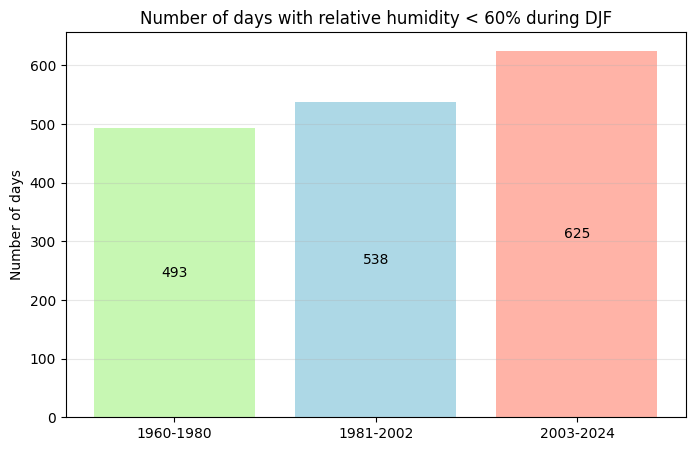

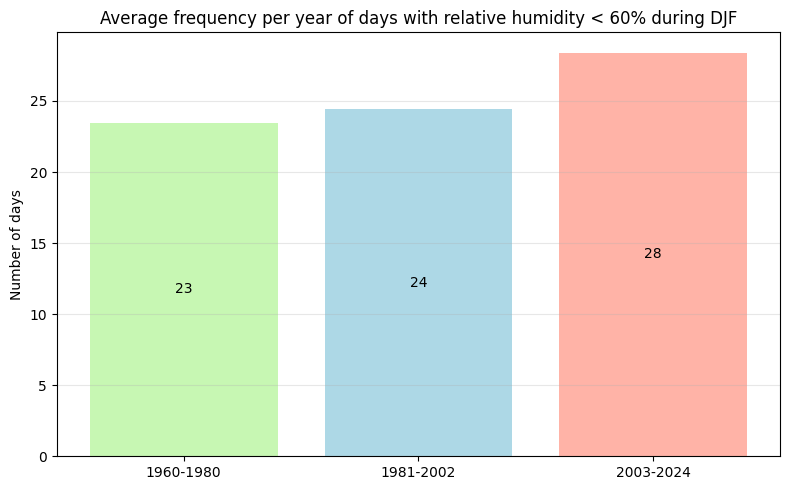

In [10]:
sr_twenty_f = sr_thresholds_d.loc["1960-01-01 00:00:00":"1980-12-31 23:00:00"]
sr_twenty_s = sr_thresholds_d.loc["1981-01-01 00:00:00":"2002-12-31 23:00:00"]
sr_twenty_t = sr_thresholds_d.loc["2003-01-01 00:00:00":"2024-12-31 23:00:00"]
list_max = [sr_twenty_f, sr_twenty_s, sr_twenty_t]

dic_count_max_djf = cp.thresholds_serie(
    "relative humidity",
    [12, 1, 2],
    list_max,
    threshold=60,
    study_sign="<"
)

### Seasonal study

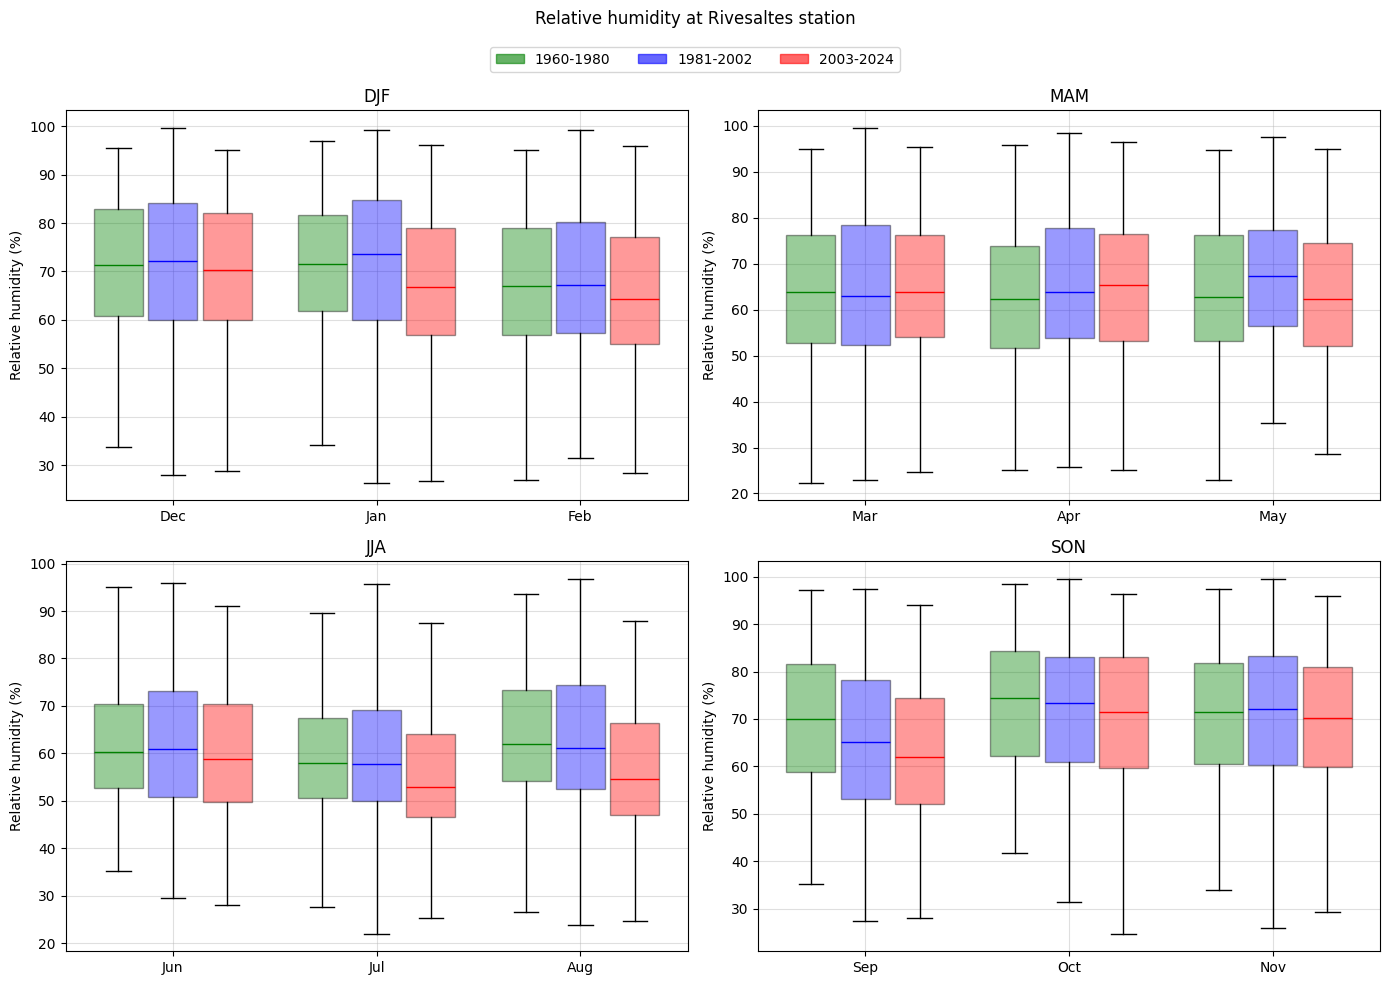

In [11]:
sr_frst_m = sr.loc["1960-01-31":"1980-12-31"].resample("D").mean()
sr_snd_m = sr.loc["1981-01-31":"2002-12-31"].resample("D").mean()
sr_thd_m = sr.loc["2003-01-31":"2024-12-31"].resample("D").mean()
sr_thd_m = sr_thd_m.dropna()
list_sr_m = [sr_frst_m, sr_snd_m, sr_thd_m] 

cp.season_box(
    list_sr_m,
    months = None,
    y_label = "Relative humidity (%)",
    title = "Relative humidity at Rivesaltes station",
    folder = "humidity" 
)
